# PHÂN TÍCH MỐI QUAN HỆ GIỮA 7 FILE OULAD

**Mục tiêu:** Phân tích cấu trúc quan hệ giữa 7 bảng OULAD, kiểm tra khóa liên kết, cardinality, orphan records và minh họa luồng join tạo dữ liệu mức sinh viên.

Khóa ghép quan trọng:

\[
StudentKey=(id\_student, code\_module, code\_presentation)
\]

Notebook này độc lập với file tuần 2.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch

OULAD_PATH = "./oulad/"
OUTPUT_DIR = "oulad_relationship_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

print("OULAD_PATH:", OULAD_PATH)
print("OUTPUT_DIR:", OUTPUT_DIR)

OULAD_PATH: ./oulad/
OUTPUT_DIR: oulad_relationship_outputs


In [2]:
courses = pd.read_csv(os.path.join(OULAD_PATH, "courses.csv"))
assessments = pd.read_csv(os.path.join(OULAD_PATH, "assessments.csv"))
studentAssessment = pd.read_csv(os.path.join(OULAD_PATH, "studentAssessment.csv"))
studentInfo = pd.read_csv(os.path.join(OULAD_PATH, "studentInfo.csv"))
studentRegistration = pd.read_csv(os.path.join(OULAD_PATH, "studentRegistration.csv"))
studentVle = pd.read_csv(os.path.join(OULAD_PATH, "studentVle.csv"))
vle = pd.read_csv(os.path.join(OULAD_PATH, "vle.csv"))

OULAD_TABLES = {
    "courses": courses,
    "assessments": assessments,
    "studentAssessment": studentAssessment,
    "studentInfo": studentInfo,
    "studentRegistration": studentRegistration,
    "studentVle": studentVle,
    "vle": vle
}

print("Đọc dữ liệu thành công.")

Đọc dữ liệu thành công.


## 1. Tổng quan 7 bảng

In [3]:
overview_rows = []

for name, df in OULAD_TABLES.items():
    overview_rows.append({
        "Table": name,
        "Rows": len(df),
        "Columns": df.shape[1],
        "Missing values": int(df.isna().sum().sum()),
        "Duplicated rows": int(df.duplicated().sum())
    })

overview = pd.DataFrame(overview_rows)
display(overview)

overview.to_csv(
    os.path.join(OUTPUT_DIR, "01_oulad_tables_overview.csv"),
    index=False
)

,Table,Rows,Columns,Missing values,Duplicated rows
0,courses,22,3,0,0
1,assessments,206,6,11,0
2,studentAssessment,173912,5,173,0
3,studentInfo,32593,12,1111,0
4,studentRegistration,32593,5,22566,0
5,studentVle,10655280,6,0,787170
6,vle,6364,6,10486,0


## 2. Vai trò và khóa liên kết

In [4]:
role_table = pd.DataFrame([
    ["courses.csv", "Thông tin học phần và kỳ mở", "code_module + code_presentation"],
    ["studentInfo.csv", "Hồ sơ và kết quả cuối của sinh viên", "id_student + code_module + code_presentation"],
    ["studentRegistration.csv", "Ngày đăng ký và ngày rút học", "id_student + code_module + code_presentation"],
    ["assessments.csv", "Thông tin bài đánh giá", "id_assessment; code_module + code_presentation"],
    ["studentAssessment.csv", "Điểm và lịch sử nộp bài", "id_student + id_assessment"],
    ["vle.csv", "Danh mục tài nguyên LMS", "id_site + code_module + code_presentation"],
    ["studentVle.csv", "Hành vi tương tác LMS", "id_student + id_site + code_module + code_presentation"]
], columns=["File", "Vai trò", "Khóa/liên kết"])

display(role_table)

role_table.to_csv(
    os.path.join(OUTPUT_DIR, "02_oulad_table_roles.csv"),
    index=False
)

,File,Vai trò,Khóa/liên kết
0,courses.csv,Thông tin học phần và kỳ mở,code_module + code_presentation
1,studentInfo.csv,Hồ sơ và kết quả cuối của sinh viên,id_student + code_module + code_presentation
2,studentRegistration.csv,Ngày đăng ký và ngày rút học,id_student + code_module + code_presentation
3,assessments.csv,Thông tin bài đánh giá,id_assessment; code_module + code_presentation
4,studentAssessment.csv,Điểm và lịch sử nộp bài,id_student + id_assessment
5,vle.csv,Danh mục tài nguyên LMS,id_site + code_module + code_presentation
6,studentVle.csv,Hành vi tương tác LMS,id_student + id_site + code_module + code_pres...


## 3. Kiểm tra tính duy nhất của khóa

In [5]:
KEY_CHECKS = [
    ("courses", ["code_module", "code_presentation"]),
    ("assessments", ["id_assessment"]),
    ("vle", ["code_module", "code_presentation", "id_site"]),
    ("studentInfo", ["code_module", "code_presentation", "id_student"]),
    ("studentRegistration", ["code_module", "code_presentation", "id_student"])
]

rows = []

for table_name, keys in KEY_CHECKS:
    df = OULAD_TABLES[table_name]
    duplicated = int(df.duplicated(subset=keys).sum())

    rows.append({
        "Table": table_name,
        "Key": " + ".join(keys),
        "Rows": len(df),
        "Duplicated key": duplicated,
        "Unique key": duplicated == 0
    })

key_check_df = pd.DataFrame(rows)
display(key_check_df)

key_check_df.to_csv(
    os.path.join(OUTPUT_DIR, "03_key_uniqueness.csv"),
    index=False
)

,Table,Key,Rows,Duplicated key,Unique key
0,courses,code_module + code_presentation,22,0,True
1,assessments,id_assessment,206,0,True
2,vle,code_module + code_presentation + id_site,6364,0,True
3,studentInfo,code_module + code_presentation + id_student,32593,0,True
4,studentRegistration,code_module + code_presentation + id_student,32593,0,True


## 4. Kiểm tra quan hệ parent-child, cardinality và orphan records

In [6]:
RELATIONS = [
    {"parent": "courses", "child": "studentInfo",
     "keys": ["code_module", "code_presentation"]},

    {"parent": "courses", "child": "studentRegistration",
     "keys": ["code_module", "code_presentation"]},

    {"parent": "courses", "child": "assessments",
     "keys": ["code_module", "code_presentation"]},

    {"parent": "courses", "child": "vle",
     "keys": ["code_module", "code_presentation"]},

    {"parent": "assessments", "child": "studentAssessment",
     "keys": ["id_assessment"]},

    {"parent": "vle", "child": "studentVle",
     "keys": ["code_module", "code_presentation", "id_site"]},

    {"parent": "studentInfo", "child": "studentRegistration",
     "keys": ["code_module", "code_presentation", "id_student"]}
]

In [7]:
def check_relation(parent_df, child_df, keys, parent_name, child_name):
    parent_keys = parent_df[keys].drop_duplicates()
    child_keys = child_df[keys].drop_duplicates()

    child_check = child_keys.merge(
        parent_keys,
        on=keys,
        how="left",
        indicator=True
    )

    orphan_child = child_check[
        child_check["_merge"] == "left_only"
    ].copy()

    parent_counts = parent_df.groupby(keys).size()
    child_counts = child_df.groupby(keys).size()

    parent_max = int(parent_counts.max()) if len(parent_counts) else 0
    child_max = int(child_counts.max()) if len(child_counts) else 0

    if parent_max == 1 and child_max == 1:
        cardinality = "1 - 1"
    elif parent_max == 1 and child_max > 1:
        cardinality = "1 - N"
    else:
        cardinality = "N - N / cần kiểm tra"

    result = {
        "Parent": parent_name,
        "Child": child_name,
        "Join key": " + ".join(keys),
        "Parent unique keys": len(parent_keys),
        "Child unique keys": len(child_keys),
        "Orphan child keys": len(orphan_child),
        "Mean child records": round(child_counts.mean(), 2),
        "Max child records": child_max,
        "Cardinality": cardinality
    }

    return result, orphan_child

In [8]:
relation_results = []
orphan_results = {}

for rel in RELATIONS:
    parent_name = rel["parent"]
    child_name = rel["child"]
    keys = rel["keys"]

    result, orphan = check_relation(
        OULAD_TABLES[parent_name],
        OULAD_TABLES[child_name],
        keys,
        parent_name,
        child_name
    )

    relation_results.append(result)
    orphan_results[parent_name + " -> " + child_name] = orphan

relation_df = pd.DataFrame(relation_results)
display(relation_df)

relation_df.to_csv(
    os.path.join(OUTPUT_DIR, "04_relationship_analysis.csv"),
    index=False
)

,Parent,Child,Join key,Parent unique keys,Child unique keys,Orphan child keys,Mean child records,Max child records,Cardinality
0,courses,studentInfo,code_module + code_presentation,22,22,0,1481.50,2498,1 - N
1,courses,studentRegistration,code_module + code_presentation,22,22,0,1481.50,2498,1 - N
2,courses,assessments,code_module + code_presentation,22,22,0,9.36,14,1 - N
3,courses,vle,code_module + code_presentation,22,22,0,289.27,529,1 - N
4,assessments,studentAssessment,id_assessment,206,188,0,925.06,1917,1 - N
5,vle,studentVle,code_module + code_presentation + id_site,6364,6268,0,1699.95,157590,1 - N
6,studentInfo,studentRegistration,code_module + code_presentation + id_student,32593,32593,0,1.00,1,1 - 1


In [9]:
for relation_name, orphan_df in orphan_results.items():
    print("=" * 75)
    print(relation_name)
    print("Orphan child keys:", len(orphan_df))

    if len(orphan_df) > 0:
        display(orphan_df.head(10))

courses -> studentInfo
Orphan child keys: 0
courses -> studentRegistration
Orphan child keys: 0
courses -> assessments
Orphan child keys: 0
courses -> vle
Orphan child keys: 0
assessments -> studentAssessment
Orphan child keys: 0
vle -> studentVle
Orphan child keys: 0
studentInfo -> studentRegistration
Orphan child keys: 0


## 5. Kiểm tra quan hệ studentInfo ↔ studentVle theo StudentKey

In [10]:
STUDENT_KEY = [
    "code_module",
    "code_presentation",
    "id_student"
]

student_info_keys = studentInfo[STUDENT_KEY].drop_duplicates()
student_vle_keys = studentVle[STUDENT_KEY].drop_duplicates()

student_vle_check = student_vle_keys.merge(
    student_info_keys,
    on=STUDENT_KEY,
    how="left",
    indicator=True
)

student_vle_orphans = student_vle_check[
    student_vle_check["_merge"] == "left_only"
].copy()

print("StudentKey trong studentInfo:", len(student_info_keys))
print("StudentKey trong studentVle:", len(student_vle_keys))
print("StudentKey studentVle không tìm thấy trong studentInfo:", len(student_vle_orphans))

if len(student_vle_orphans) > 0:
    display(student_vle_orphans.head(10))

StudentKey trong studentInfo: 32593
StudentKey trong studentVle: 29228
StudentKey studentVle không tìm thấy trong studentInfo: 0


## 6. Minh họa luồng join tạo dataset mức sinh viên

In [11]:
profile_data = studentInfo.merge(
    studentRegistration,
    on=STUDENT_KEY,
    how="left",
    suffixes=("_info", "_registration")
)

profile_data = profile_data.merge(
    courses,
    on=["code_module", "code_presentation"],
    how="left"
)

print("Profile data:", profile_data.shape)

Profile data: (32593, 15)


In [12]:
assessment_data = studentAssessment.merge(
    assessments,
    on="id_assessment",
    how="left",
    suffixes=("_student", "_assessment")
)

assessment_features = (
    assessment_data
    .groupby(STUDENT_KEY)
    .agg(
        assessment_count=("id_assessment", "nunique"),
        avg_score=("score", "mean"),
        submitted_count=("date_submitted", "count")
    )
    .reset_index()
)

print("Assessment features:", assessment_features.shape)

Assessment features: (25843, 6)


In [13]:
vle_data = studentVle.merge(
    vle[
        [
            "code_module",
            "code_presentation",
            "id_site",
            "activity_type"
        ]
    ],
    on=[
        "code_module",
        "code_presentation",
        "id_site"
    ],
    how="left"
)

vle_features = (
    vle_data
    .groupby(STUDENT_KEY)
    .agg(
        total_clicks=("sum_click", "sum"),
        active_days=("date", "nunique"),
        activity_types=("activity_type", "nunique"),
        last_activity_day=("date", "max")
    )
    .reset_index()
)

print("VLE features:", vle_features.shape)

VLE features: (29228, 7)


In [14]:
model_level_data = profile_data.merge(
    assessment_features,
    on=STUDENT_KEY,
    how="left"
)

model_level_data = model_level_data.merge(
    vle_features,
    on=STUDENT_KEY,
    how="left"
)

print("Student-level dataset:", model_level_data.shape)
display(model_level_data.head())

Student-level dataset: (32593, 22)


,code_module,code_presentation,id_student,gender,region,highest_education,imd_band,age_band,num_of_prev_attempts,studied_credits,...,date_registration,date_unregistration,module_presentation_length,assessment_count,avg_score,submitted_count,total_clicks,active_days,activity_types,last_activity_day
0,AAA,2013J,11391,M,East Anglian Region,HE Qualification,90-100%,55<=,0,240,...,-159.0,NaN,268,5.0,82.0,5.0,934.0,40.0,6.0,253.0
1,AAA,2013J,28400,F,Scotland,HE Qualification,20-30%,35-55,0,60,...,-53.0,NaN,268,5.0,66.4,5.0,1435.0,80.0,7.0,239.0
2,AAA,2013J,30268,F,North Western Region,A Level or Equivalent,30-40%,35-55,0,60,...,-92.0,12.0,268,NaN,NaN,NaN,281.0,12.0,6.0,12.0
3,AAA,2013J,31604,F,South East Region,A Level or Equivalent,50-60%,35-55,0,60,...,-52.0,NaN,268,5.0,76.0,5.0,2158.0,123.0,8.0,264.0
4,AAA,2013J,32885,F,West Midlands Region,Lower Than A Level,50-60%,0-35,0,60,...,-176.0,NaN,268,5.0,54.4,5.0,1034.0,70.0,7.0,247.0


## 7. Vẽ sơ đồ quan hệ 7 bảng OULAD

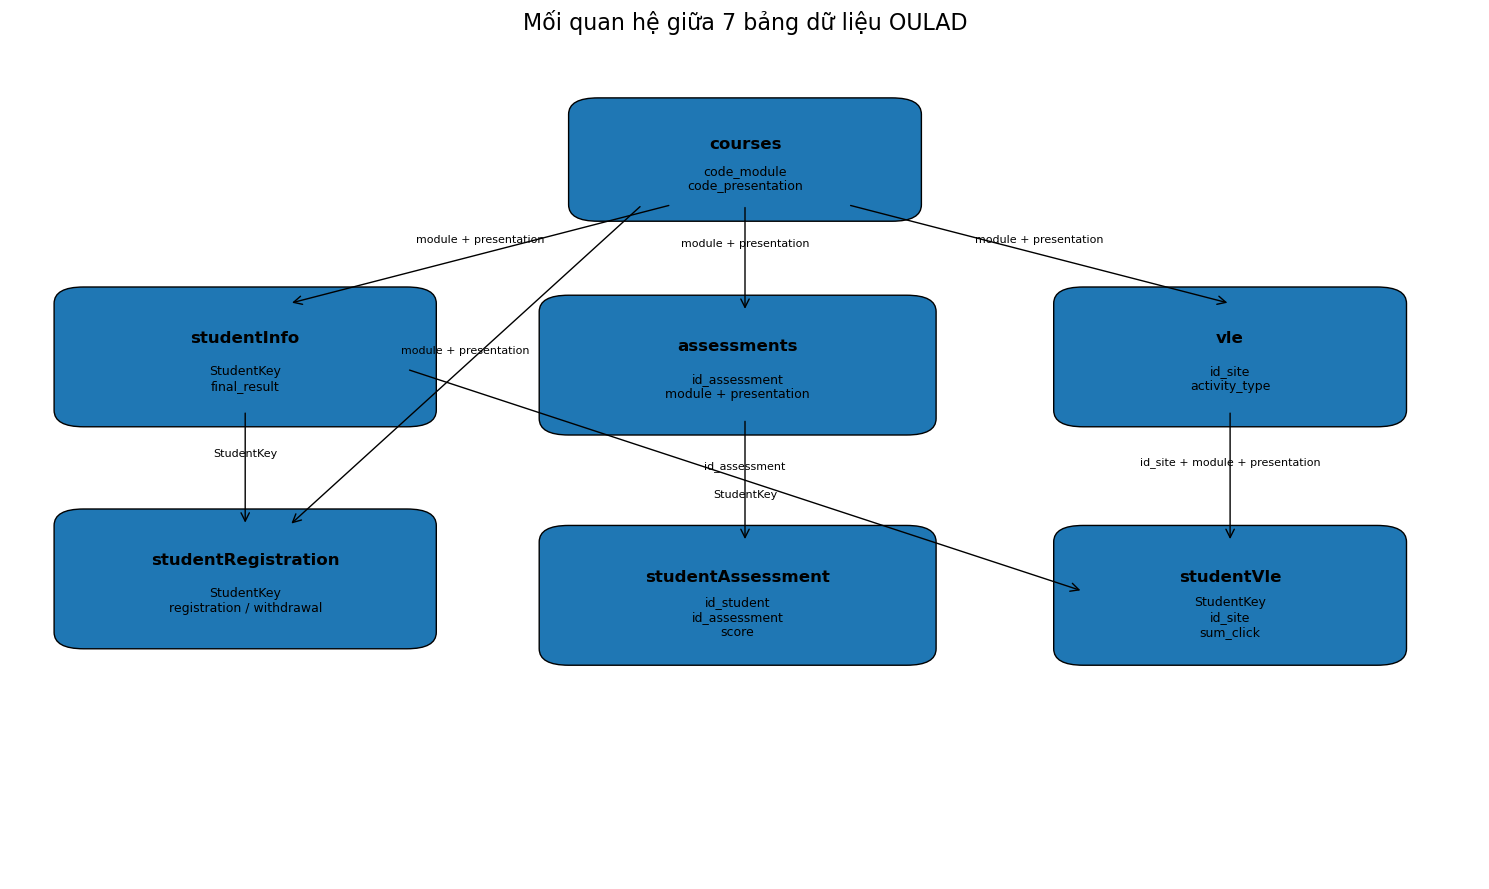

Đã lưu hình: oulad_relationship_outputs\OULAD_7_tables_relationship.png


In [15]:
fig, ax = plt.subplots(figsize=(15, 9))

ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.axis("off")

def table_box(x, y, w, h, title, subtitle):
    box = FancyBboxPatch(
        (x, y),
        w,
        h,
        boxstyle="round,pad=0.02"
    )
    ax.add_patch(box)

    ax.text(
        x + w/2,
        y + h*0.68,
        title,
        ha="center",
        va="center",
        fontsize=12,
        fontweight="bold"
    )

    ax.text(
        x + w/2,
        y + h*0.30,
        subtitle,
        ha="center",
        va="center",
        fontsize=9
    )

def relation_arrow(start, end, label, label_offset=0.015):
    arrow = FancyArrowPatch(
        start,
        end,
        arrowstyle="->",
        mutation_scale=15
    )
    ax.add_patch(arrow)

    mid_x = (start[0] + end[0]) / 2
    mid_y = (start[1] + end[1]) / 2

    ax.text(
        mid_x,
        mid_y + label_offset,
        label,
        fontsize=8,
        ha="center"
    )

table_box(0.40, 0.82, 0.20, 0.11, "courses",
          "code_module\ncode_presentation")

table_box(0.05, 0.57, 0.22, 0.13, "studentInfo",
          "StudentKey\nfinal_result")

table_box(0.05, 0.30, 0.22, 0.13, "studentRegistration",
          "StudentKey\nregistration / withdrawal")

table_box(0.38, 0.56, 0.23, 0.13, "assessments",
          "id_assessment\nmodule + presentation")

table_box(0.38, 0.28, 0.23, 0.13, "studentAssessment",
          "id_student\nid_assessment\nscore")

table_box(0.73, 0.57, 0.20, 0.13, "vle",
          "id_site\nactivity_type")

table_box(0.73, 0.28, 0.20, 0.13, "studentVle",
          "StudentKey\nid_site\nsum_click")

relation_arrow((0.45, 0.82), (0.19, 0.70),
               "module + presentation")

relation_arrow((0.43, 0.82), (0.19, 0.43),
               "module + presentation")

relation_arrow((0.50, 0.82), (0.50, 0.69),
               "module + presentation")

relation_arrow((0.57, 0.82), (0.83, 0.70),
               "module + presentation")

relation_arrow((0.50, 0.56), (0.50, 0.41),
               "id_assessment")

relation_arrow((0.83, 0.57), (0.83, 0.41),
               "id_site + module + presentation")

relation_arrow((0.16, 0.57), (0.16, 0.43),
               "StudentKey")

relation_arrow((0.27, 0.62), (0.73, 0.35),
               "StudentKey", label_offset=-0.02)

ax.set_title(
    "Mối quan hệ giữa 7 bảng dữ liệu OULAD",
    fontsize=16,
    pad=20
)

plt.tight_layout()

schema_path = os.path.join(
    OUTPUT_DIR,
    "OULAD_7_tables_relationship.png"
)

plt.savefig(
    schema_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Đã lưu hình:", schema_path)

## 8. Kết luận

OULAD được tổ chức theo cấu trúc quan hệ. Ba nhóm khóa quan trọng:

- Khóa học phần: `(code_module, code_presentation)`
- Khóa sinh viên theo học phần/kỳ: `(id_student, code_module, code_presentation)`
- Khóa hoạt động/đánh giá: `id_site`, `id_assessment`

Luồng tổng quát:

**Hồ sơ + đăng ký + điểm + hành vi LMS → Student-level dataset → mô hình cảnh báo sớm**

In [16]:
model_level_data.to_csv(
    os.path.join(
        OUTPUT_DIR,
        "05_student_level_join_demo.csv"
    ),
    index=False
)

print("Các file đã tạo:")

for file_name in sorted(os.listdir(OUTPUT_DIR)):
    print("-", file_name)

Các file đã tạo:
- 01_oulad_tables_overview.csv
- 02_oulad_table_roles.csv
- 03_key_uniqueness.csv
- 04_relationship_analysis.csv
- 05_student_level_join_demo.csv
- OULAD_7_tables_relationship.png
